<a href="https://colab.research.google.com/github/teemus28/Deep-Learning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Single perceptron


In [ ]:
xor_data = {'x1':[1,0,1,0],'x2':[1,1,0,0],'y':[0,1,1,0]}

In [ ]:
import pandas as pd

In [ ]:
xor_data = pd.DataFrame(xor_data)

<Axes: xlabel='x1', ylabel='x2'>

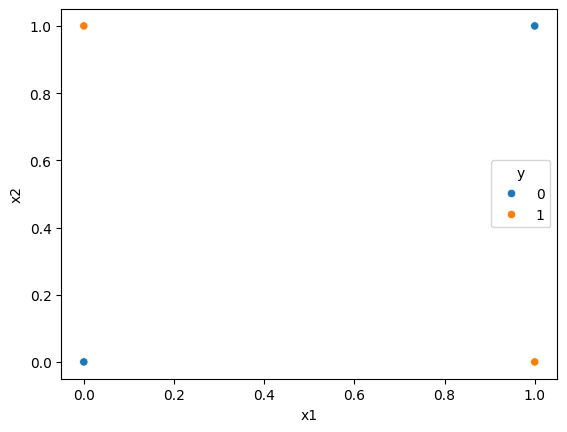

In [ ]:
import seaborn as sbn
sbn.scatterplot(x = xor_data['x1'],y = xor_data['x2'],hue = xor_data['y'])

In [ ]:
def step_function(z):
  return 1 if z > 0 else 0

In [ ]:
import numpy as np

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [ ]:
#1 initialize weights and bias - w0,w1,w2 - 1
#2 epoch
   # Take 1 row
     # z = w0 + w1X1 + W2X2    (W.X)
     # Wnew = Wold - (lr)*dl/dw     ,          dl/dw = -(yi-y_hat).X
     # Wnew = Wold + (lr)*(yi-y_hat).Xi

#3 get Wnew
# intercept_ - W[0] , coef_ - W[1:]
# we have w0 + w1X1 + W2X2 = 0

#4 line - y = m*X+b
# X2 = (-W1/W2)X1 + (-W0/W2)


In [ ]:
def My_perceptron(X,y,lr=0.1,epoch=10):
  X = np.insert(X,0,1,axis=1)  #adding column containig 1 at 0th index
  weights = np.ones(X.shape[1])  # shape[1] - columns (3 cols - 1,x1,x2) , initializing w8 and bias
  for i in range(epoch):
    for j in range(X.shape[0]):               #stochastic GD
      z = np.dot(X[j],weights)
      y_hat = step_function(z)
      weights = weights + lr*(y[j]-y_hat)*X[j]
  return weights[0],weights[1:]

In [ ]:
intercept_ , coef_ = My_perceptron(xor_data[['x1','x2']].values,xor_data['y'].values)

In [ ]:
print(intercept_,coef_)

-0.09999999999999987 [0.2 0.2]


In [ ]:
m = -coef_[0]/coef_[1]
b = -intercept_/coef_[1]

In [ ]:
x_new = np.linspace(0,1,20)
y_new = m*x_new + b

In [ ]:
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'xor_data')

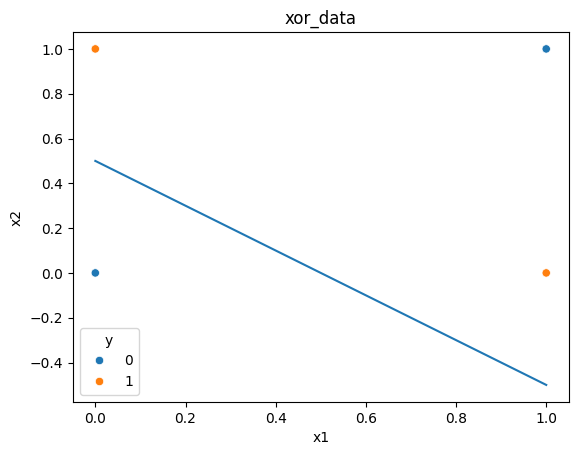

In [ ]:
sbn.scatterplot(x='x1', y='x2', hue='y', data=xor_data)
plt.plot(x_new,y_new)
plt.title('xor_data')

In [ ]:
#inbuilt perceptron
from sklearn.linear_model import Perceptron
clf = Perceptron()

In [ ]:
clf.fit(xor_data[['x1','x2']],xor_data['y'])

Perceptron()

In [ ]:
clf.predict(np.array([[0,1]]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


array([0])

In [ ]:
y_pred = clf.predict(xor_data[['x1','x2']])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(xor_data['y'], y_pred)

0.5

In [ ]:
clf.intercept_

array([0.])

In [ ]:
clf.coef_

array([[0., 0.]])

In [ ]:
#  Conclusion - Single perceptron is not for XOR data

In [ ]:
# hyperparameter of perceptron - epochs , learning rate , weights , bias , batch_size (for mini_batch GD) , activation function

Multi Layer Perceptron


In [ ]:
xor_data

,x1,x2,y
0,1,1,0
1,0,1,1
2,1,0,1
3,0,0,0


In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
model = Sequential()
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [ ]:
history = model.fit(xor_data[['x1','x2']],xor_data['y'],epochs=20)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5000 - loss: 0.7429
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.5000 - loss: 0.7422
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 0.7416
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5000 - loss: 0.7409
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.5000 - loss: 0.7403
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5000 - loss: 0.7396
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.7390
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5000 - loss: 0.7383
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.7377
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 0.7370
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5000 - loss: 0.7364
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5000 - loss: 0.7358
Ep

In [ ]:
np.array([[0,1]])

array([[0, 1]])

In [ ]:
model.predict(np.array([[0,1]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[0.5353236]], dtype=float32)

In [ ]:
y_prob = model.predict(xor_data[['x1','x2']])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
y_pred = np.where(y_prob>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(xor_data['y'], y_pred)

0.5

In [ ]:
# ANN - forward propogation + backward propogation

In [ ]:
# hyperparameters - no. of layers , no. of perceptron in each layer , activation function of each layer , optimizer , loss function

Vanishing GD

In [ ]:
# Wnew = Wold - (lr)*dl/dw    (GD)

# In vanishing GD , dl/dw - very small due to
    # 1. sigmoid and tanh in hidden layers
    # 2. large no. of layers

# due to this weight updates is very less

# soln - 1. apply relu in hidden layers (or decrease hidden layers - only sometimes)
      #2 decrease hidden layers - only sometimes
      #3 apply proper weight initialization technique
      #4 batch normalization

In [ ]:
from sklearn.datasets import make_moons
X,y = make_moons(n_samples=250, noise=0.05, random_state=42)

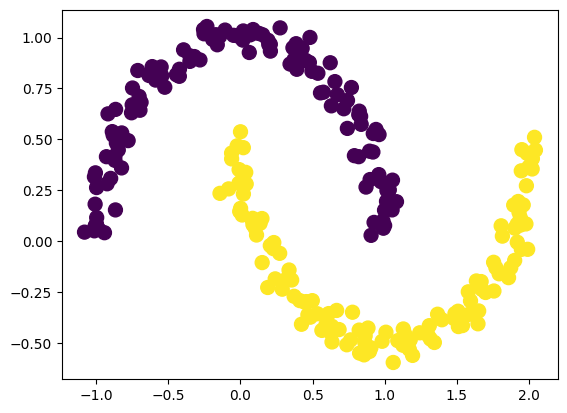

In [ ]:
plt.scatter(X[:,0],X[:,1], c=y, s=100)
plt.show()

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential ()
model.add(Dense(10,activation='sigmoid',input_dim=2))    # 11 hidden layers containing 10 perceptrons each
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(10,activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
old_weights = model.get_weights()[0]

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
model.fit(X_train,y_train,epochs=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4854 - loss: 0.7237


In [ ]:
new_weights = model.get_weights()[0]      # very less change

In [ ]:
model.optimizer.get_config()["learning_rate"]

0.0010000000474974513

In [ ]:
gradient = (old_weights - new_weights)/ 0.001       # wn = wo - lr*(dl/dw)    ->     dl/dw = (wo - wn)/lr
gradient

array([[ 0.00711158,  0.00202656,  0.00081956,  0.00062585, -0.00393391,
        -0.01245737, -0.00837445,  0.00075251, -0.00621378,  0.00587106],
       [-0.00906581, -0.00274181, -0.00101328, -0.00071526,  0.00500679,
         0.01597404,  0.01086295, -0.00089407,  0.0077486 , -0.00730157]],
      dtype=float32)

In [ ]:
percent_change = abs(100*(old_weights - new_weights)/ old_weights)
percent_change

array([[1.7536284e-02, 1.1931139e-03, 1.7107161e-03, 1.5819288e-04,
        7.6918135e-04, 3.0737559e-03, 3.0150998e-03, 6.4945285e-04,
        3.2643217e-03, 4.6508070e-03],
       [1.0339837e+01, 6.4421486e-04, 1.6053066e-04, 1.8118969e-04,
        7.1215682e-04, 3.1718179e-03, 5.6111231e-03, 1.7149633e-04,
        1.1992069e-03, 1.6602175e-03]], dtype=float32)

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
old_weights = model.get_weights()[0]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model.fit(X_train, y_train, epochs = 1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.4399 - loss: 0.6935


In [ ]:
new_weights = model.get_weights()[0]

In [ ]:
gradient = (old_weights - new_weights)/ 0.001
percent_change = abs(100*(old_weights - new_weights)/ old_weights)

In [ ]:
gradient

array([[ 4.3754277 ,  4.616078  , -3.7691963 , -4.447132  , -2.6241539 ,
         1.7403661 , -4.3089685 ,  0.22912024,  4.221415  , -4.280746  ],
       [-3.9091854 ,  3.007382  ,  3.741741  ,  4.0327907 ,  3.0238328 ,
        -4.92692   , -2.171129  ,  3.080785  ,  2.9427109 ,  4.0101705 ]],
      dtype=float32)

In [ ]:
percent_change

array([[ 0.9150097 ,  8.930243  ,  6.03714   ,  1.9479175 ,  0.5327257 ,
         0.9842379 ,  1.0298005 ,  0.09532709, 17.850578  ,  0.75093365],
       [ 2.2305958 ,  0.78475225,  0.70036995,  0.6310444 ,  0.61559594,
         0.8365783 ,  0.5375403 ,  1.0924299 ,  0.6335803 ,  1.3181804 ]],
      dtype=float32)

In [ ]:
# exploding GD , dl/dw - large
# soln - gradient clipping (in RNN)

Improving Neural networks


In [ ]:
#1 fine tuning NN hyperparameters

# epochs (use early stopping)
# no. of hidden layers
# activation function   ( relu in hidden layers)
# no. of perceptrons in each layer
# lr
# optimizer
# batch size   (8-32)
# weights , bias  (weight initialization)
#

In [ ]:
#2 By solving problems

# vanishing and exploding GD
   # use relu (in hidden layers)
   # Batch normalization
   # weight initialization
   # gradient clipping (for exploding GD)


# not enough data
   # transfer learning
   # unsupervised pretraining

# slow training
    # optimizer
    # learning rate scheduler

# overfitting
   # l1,l2 regularization
   # dropout
   # Early stopping

# Early Stopping

In [ ]:
# if epoch = 100000 , then sometimes it leads to overfitting so we stop training at that point where overfitting begins

In [ ]:
from sklearn.datasets import make_circles

In [ ]:
X,y = make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

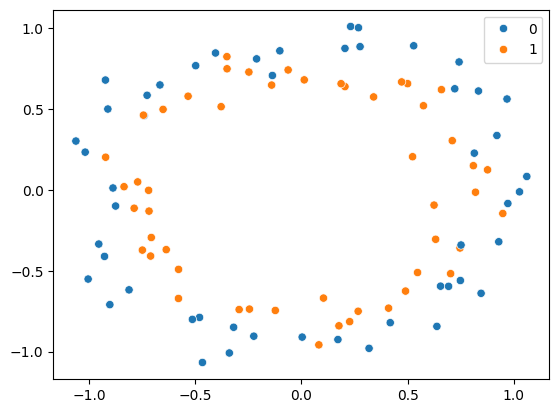

In [ ]:
sbn.scatterplot(x=X[:,0],y=X[:,1],hue=y)

In [ ]:
model = Sequential()
model.add(Dense(256,activation='relu',input_dim=2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss = 'binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
callback = EarlyStopping(
    monitor="val_loss",      # if validation loss increases it will stop
    min_delta=0.00001,       # how much should loss change
    patience=25, # how many eochs we can wait for
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False
)

In [ ]:
history = model.fit(X_train,y_train,epochs=1000,validation_data=(X_test,y_test),callbacks=callback)

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step - accuracy: 0.4781 - loss: 0.6952 - val_accuracy: 0.4500 - val_loss: 0.7032
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5500 - loss: 0.6886 - val_accuracy: 0.4500 - val_loss: 0.7022
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5422 - loss: 0.6890 - val_accuracy: 0.4500 - val_loss: 0.7007
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5547 - loss: 0.6900 - val_accuracy: 0.5500 - val_loss: 0.6990
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5813 - loss: 0.6908 - val_accuracy: 0.4500 - val_loss: 0.6974
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6047 - loss: 0.6879 - val_accuracy: 0.4000 - val_loss: 0.6961
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5930 - loss: 0.6890 - val_accuracy: 0.4500 - val_loss: 0.6960
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6273 - loss: 0.6893 - val_accuracy: 0.4500 - 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


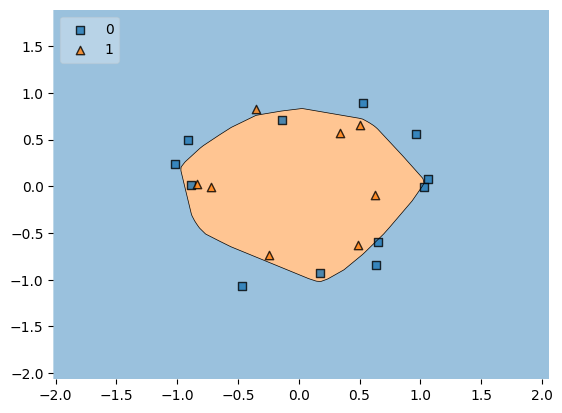

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()

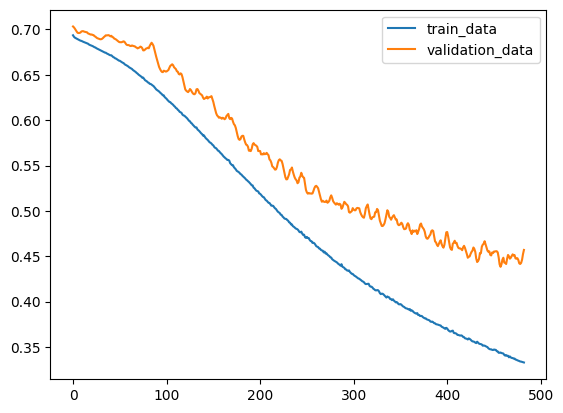

In [ ]:
plt.plot(history.history['loss'], label='train_data')
plt.plot(history.history['val_loss'], label='validation_data')
plt.legend()
plt.show()